In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import get_gamma, envelope_max_mean

In [2]:
data = pd.read_csv('../data/session-4/od5dokonca.csv')
data['t'] += 300 # the starting time is 1 minute
# data = data.drop(data.index[0:700]).dropna()
data = data.dropna()

In [3]:
print(data.head())

        t    mass A    mass B    mass C    mass D
0   300.0  0.006338 -0.016900 -0.025350  0.004225
15  300.5  0.002704 -0.022610 -0.022540  0.000399
18  300.6  0.003451 -0.011540 -0.007138 -0.014240
21  300.7  0.004117  0.000797  0.009560 -0.027420
24  300.8  0.005088  0.014020  0.026290 -0.037380


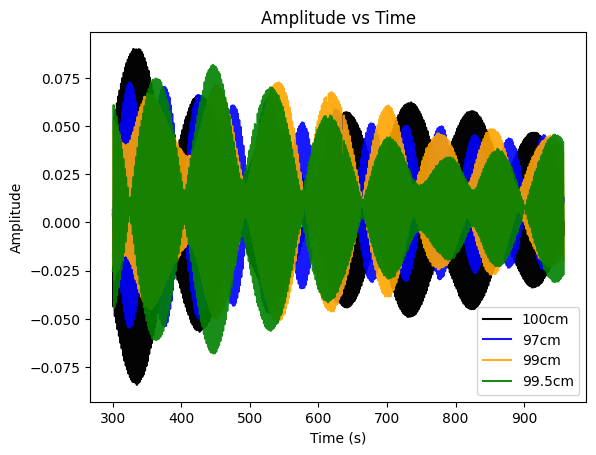

In [4]:
plt.plot(data['t'], data['mass D'], color='black', label='100cm', alpha=0.99)
plt.plot(data['t'], data['mass A'], color='blue', label='97cm', alpha=0.9)
plt.plot(data['t'], data['mass B'], color='orange', label='99cm', alpha=0.9)
plt.plot(data['t'], data['mass C'], color='green', label='99.5cm', alpha=0.9)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Amplitude vs Time')
plt.legend()
plt.show()

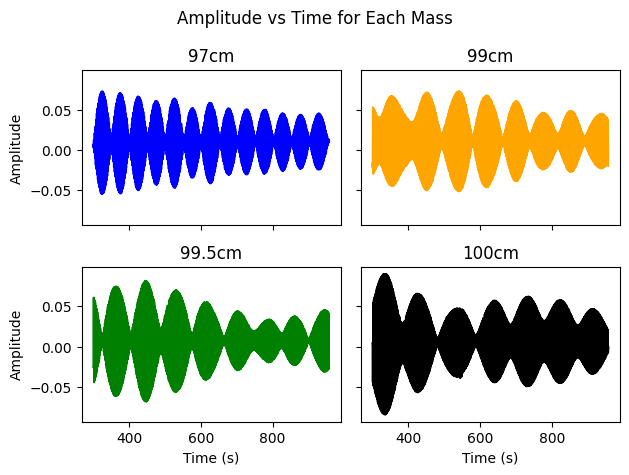

In [5]:
fig, axd = plt.subplot_mosaic([['A', 'B'], ['C', 'D']], sharex=True, sharey=True)

opacity = 1

axd['A'].plot(data['t'], data['mass A'], color='blue', label='97cm', alpha=opacity)
axd['A'].set_title('97cm')
axd['B'].plot(data['t'], data['mass B'], color='orange', label='99cm', alpha=opacity)
axd['B'].set_title('99cm')
axd['C'].plot(data['t'], data['mass C'], color='green', label='99.5cm', alpha=opacity)
axd['C'].set_title('99.5cm')
axd['D'].plot(data['t'], data['mass D'], color='black', label='100cm', alpha=opacity)
axd['D'].set_title('100cm')

axd['A'].set_ylabel('Amplitude')
axd['C'].set_ylabel('Amplitude')
axd['C'].set_xlabel('Time (s)')
axd['D'].set_xlabel('Time (s)')

plt.suptitle('Amplitude vs Time for Each Mass')
plt.tight_layout()

plt.suptitle('Amplitude vs Time for Each Mass')
plt.show()

In [6]:
g = 9.81
L = np.array([0.97, 0.99, 0.995, 1.00])
L_d = 1

t_arr = data['t'].to_numpy()
cols = ('mass A', 'mass B', 'mass C', 'mass D')
labels = ('97cm', '99cm', '99.5cm', '100cm')
results = {col: envelope_max_mean(t_arr, data[col].to_numpy()) for col in cols}

A = np.array([results[c][0] for c in cols])

for col, label in zip(cols, labels):
    mean, peak_t, peak_h = results[col]
    print(f'{label}: {len(peak_t)} envelope peaks, mean={mean:.4f}')

gamma, err = get_gamma(L_d, A, L, g)
print(f'Gamma: {gamma:.4f} ± {err:.4f}')

97cm: 26 envelope peaks, mean=0.0468
99cm: 14 envelope peaks, mean=0.0511
99.5cm: 12 envelope peaks, mean=0.0545
100cm: 14 envelope peaks, mean=0.0556
L_d: 1, A: [0.04683885 0.05112929 0.05448583 0.05562214], L: [0.97  0.99  0.995 1.   ], g: 9.81
Omega_d: 3.132091952673165, Omega_0: [3.18015755 3.14787085 3.13995167 3.13209195], A_norm: [0.84208993 0.91922539 0.97957091 1.        ]
Fit result - Gamma: 0.14495325226869835, Error: 0.01942807300151849
Gamma: 0.1450 ± 0.0194


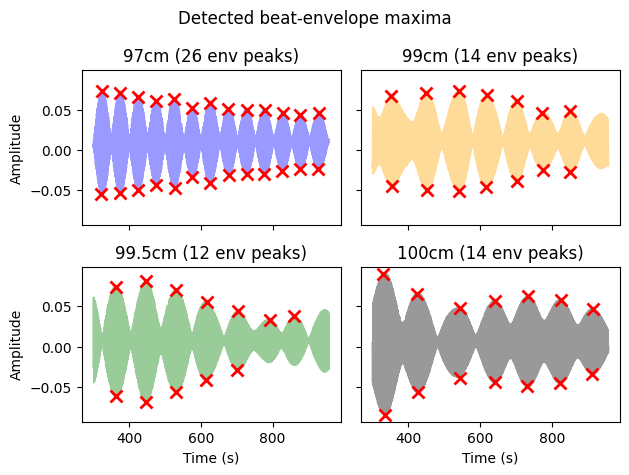

In [7]:
fig, axd = plt.subplot_mosaic([['A', 'B'], ['C', 'D']], sharex=True, sharey=True)
panels = [
    ('A', 'blue',   '97cm',   'mass A'),
    ('B', 'orange', '99cm',   'mass B'),
    ('C', 'green',  '99.5cm', 'mass C'),
    ('D', 'black',  '100cm',  'mass D'),
]
for key, color, label, col in panels:
    _, peak_t, peak_h_signed = results[col]
    axd[key].plot(data['t'], data[col], color=color, alpha=0.4)
    axd[key].plot(peak_t, peak_h_signed, 'rx', markersize=9, mew=2)
    axd[key].set_title(f'{label} ({len(peak_t)} env peaks)')

axd['A'].set_ylabel('Amplitude')
axd['C'].set_ylabel('Amplitude')
axd['C'].set_xlabel('Time (s)')
axd['D'].set_xlabel('Time (s)')

plt.suptitle('Detected beat-envelope maxima')
plt.tight_layout()
plt.show()

In [8]:
def resonance_norm(omega_d, omega_i, omega_i_max_A, gamma):
    numerator = (omega_i_max_A**2 - omega_d**2)**2 + (gamma * omega_d)**2
    denominator = (omega_i**2 - omega_d**2)**2 + (gamma * omega_d)**2
    return np.sqrt(numerator / denominator)

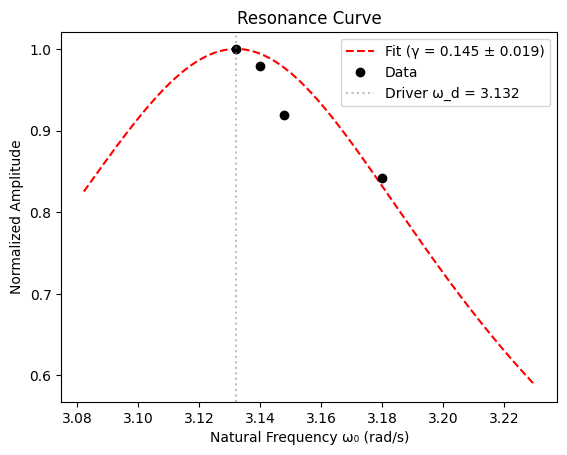

In [9]:
A_norm = A / A.max()
omega_0 = np.sqrt(g / L)
omega_d = np.sqrt(g / L_d)
omega_0_max = omega_0[A.argmax()]

omega_range = np.linspace(omega_0.min() - 0.05, omega_0.max() + 0.05, 400)
fit_vals = resonance_norm(omega_d, omega_range, omega_0_max, gamma)

plt.plot(omega_range, fit_vals, 'r--', label=f'Fit (γ = {gamma:.3f} ± {err:.3f})')
plt.plot(omega_0, A_norm, 'ko', label='Data')
plt.axvline(omega_d, color='gray', linestyle=':', alpha=0.5, label=f'Driver ω_d = {omega_d:.3f}')
plt.xlabel('Natural Frequency ω₀ (rad/s)')
plt.ylabel('Normalized Amplitude')
plt.title('Resonance Curve')
plt.legend()
plt.show()